Jacob Maurer\
3/30/2026\
1:23\
Purpose: Analyze the experimental results of the all DQN run

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

Paths:
"./experiments/euchre_dqn_train_all_more_memory/performance.csv"
"./experiments/euchre_dqn_train_all/performance.csv"


In [2]:
data = pd.read_csv("D:\\ppo_train_all\\performance.csv")
data.head()

,episode,reward,agent
0,0,-0.0040,0
1,0,-0.0100,1
2,0,0.0065,2
3,0,0.0095,3
4,100,-0.0120,0


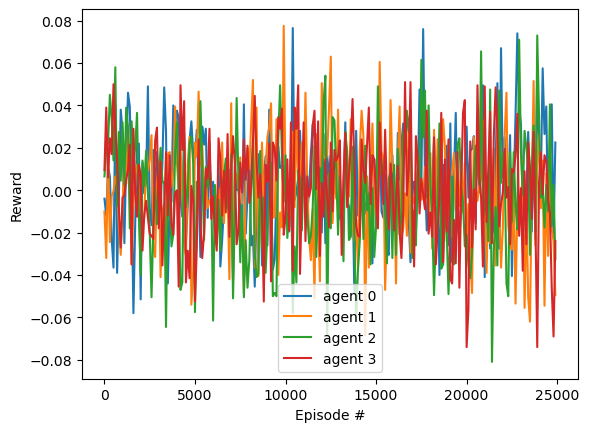

In [3]:
agent_groups = data.groupby('agent')
for index, frame in agent_groups:
    plt.plot(frame["episode"].to_numpy(), frame["reward"], label='agent ' + str(index))
plt.xlabel('Episode #')
plt.ylabel('Reward')
plt.legend()
plt.show()

In [4]:
agent_groups.mean()

,episode,reward
agent,,
0,12450.0,0.003990
1,12450.0,-0.000650
2,12450.0,-0.002466
3,12450.0,0.000864


Team 1, consisting of agent 0 and 2, won more than agents 1 and 3 on team 2. Individually, agent 2 was the best on team 1, while agent 3 was best on team two. This is for a DQN with only ReLU and linear layers.

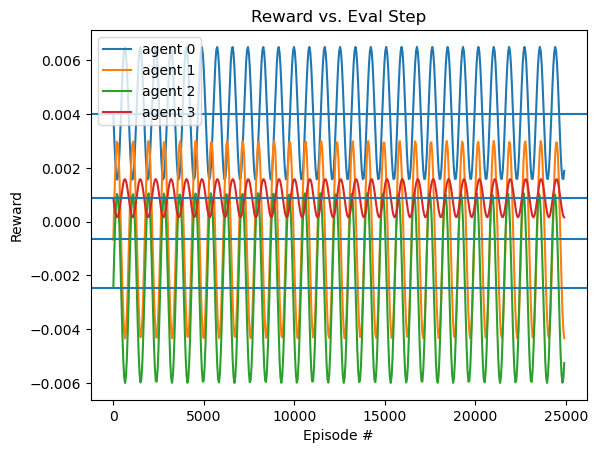

In [5]:
def sin_fit(x, a, b, c):
    return b*np.sin(a*x) + c

for index, frame in agent_groups:
    params =  curve_fit(sin_fit, frame["episode"].to_numpy(), frame["reward"].to_numpy())[0]
    fit_x = np.linspace(frame["episode"].min(), frame["episode"].max(), 500)
    fit_y = sin_fit(fit_x, params[0], params[1], params[2])
    plt.plot(fit_x, fit_y, label = 'agent ' + str(index))
    plt.axhline(frame["reward"].mean(), frame["episode"].min(), frame["episode"].max())
plt.xlabel('Episode #')
plt.ylabel('Reward')
plt.title('Reward vs. Eval Step')
plt.legend()
plt.show()

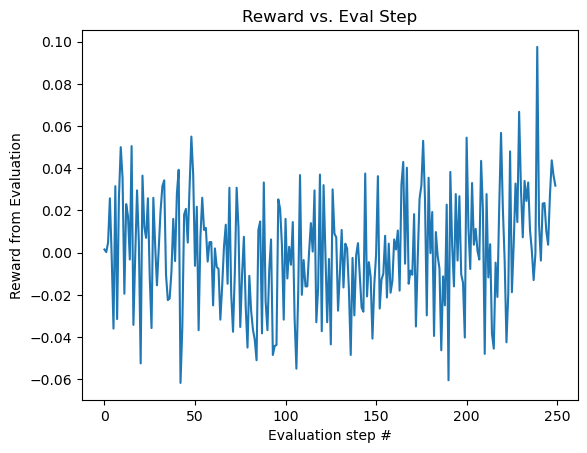

In [6]:
rewards = {}
for index, frame in agent_groups:
    rewards.update({index: frame["reward"].to_numpy()})
team_1_rewards = (rewards[0] + rewards[2])/2.0
team_2_rewards = (rewards[1] + rewards[3])/2.0

plt.plot(range(len(team_1_rewards)), team_1_rewards-team_2_rewards)
plt.xlabel('Evaluation step #')
plt.ylabel('Reward from Evaluation')
plt.title('Reward vs. Eval Step')
plt.show()